CHURN RATE PREDICTION USING XGBOOST

In [25]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier
import optuna

In [26]:
# importing the dataset
pd.set_option('display.max_columns', None)
df = pd.read_excel('../DataSet/data.xlsx')
df[df["Tenure Months"] != 0]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [27]:
df.tail()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,No,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


<Axes: xlabel='Tenure Months'>

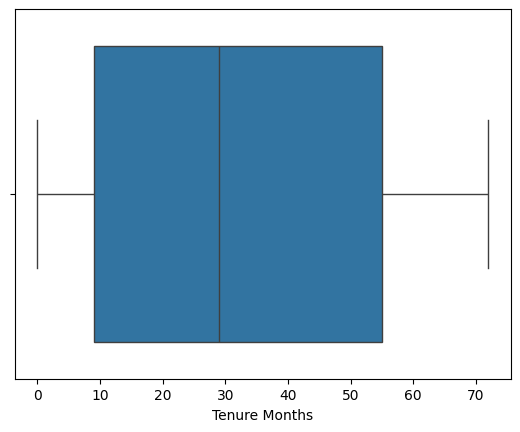

In [28]:
sns.boxplot(x=df['Tenure Months']) 

<Axes: xlabel='Monthly Charges'>

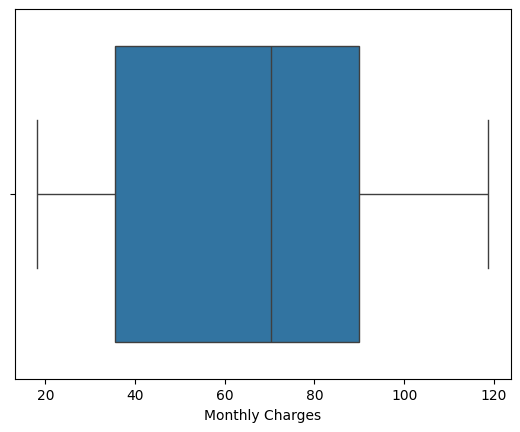

In [29]:
sns.boxplot(x=df['Monthly Charges'])

In [30]:
Y=df['Churn Value']
X= df.drop(columns=['CustomerID','Count', 'Country', 'State','Zip Code','Lat Long','Churn Value','Churn Score','Churn Label','Churn Reason','CLTV','Churn Score','CLTV','Churn Label','Churn Reason'])

In [31]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [32]:
x_test

,City,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
185,Keene,35.214982,-118.590490,Female,No,No,No,15,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),85.90,1269.55
2715,Stockton,38.002125,-121.324979,Male,No,Yes,No,18,Yes,Yes,DSL,No,Yes,No,No,No,No,Month-to-month,No,Credit card (automatic),56.80,1074.65
3825,San Leandro,37.687264,-122.157280,Female,No,No,No,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.00,40.9
1807,Sherman Oaks,34.146957,-118.432138,Male,Yes,Yes,No,6,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.20,519.15
132,Murrieta,33.581045,-117.147190,Male,No,No,No,40,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,No,Bank transfer (automatic),104.80,4131.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6366,Copperopolis,37.943954,-120.671080,Female,Yes,Yes,Yes,66,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Electronic check,104.90,6891.45
315,Modesto,37.716186,-121.025836,Male,No,No,No,19,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),86.00,1532.45
2439,Inyokern,36.041315,-118.188235,Female,No,Yes,No,2,Yes,No,Fiber optic,Yes,Yes,No,No,Yes,No,Month-to-month,No,Electronic check,90.35,190.5
5002,Danville,37.791481,-121.903253,Male,No,Yes,Yes,68,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Electronic check,110.20,7467.5


In [33]:
numerical_categories =['Latitude','Longitude','Tenure Months','Monthly Charges','Total Charges']

In [34]:
x_test["Contract"].unique

<bound method Series.unique of 185     Month-to-month
2715    Month-to-month
3825    Month-to-month
1807    Month-to-month
132     Month-to-month
             ...      
6366          One year
315     Month-to-month
2439    Month-to-month
5002          Two year
1161    Month-to-month
Name: Contract, Length: 1409, dtype: object>

In [35]:
one_hot_cat=[
    'Gender', 'City', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing', 'Payment Method'
]

In [36]:
ordinal_cat=[
    'Contract'
]

In [37]:
class Converter(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_copy = X.copy()
        X_copy['Latitude']= pd.to_numeric(X_copy['Latitude'], errors='coerce')
        X_copy['Longitude']= pd.to_numeric(X_copy['Longitude'], errors='coerce')
        X_copy['Tenure Months']= pd.to_numeric(X_copy['Tenure Months'], errors='coerce')
        X_copy['Monthly Charges']= pd.to_numeric(X_copy['Monthly Charges'], errors='coerce')
        X_copy['Total Charges']= pd.to_numeric(X_copy['Total Charges'], errors='coerce')
    
        
        return X_copy
    


In [38]:

from sklearn.impute import SimpleImputer


one_hot_pipeline= make_pipeline(
    (OneHotEncoder(handle_unknown='ignore',drop='if_binary')),
)
categorical_pipeline= make_pipeline(
    (OrdinalEncoder(categories=[['Month-to-month','One year','Two year']])),
)
numerical_pipeline= make_pipeline(
    (StandardScaler()),
    (SimpleImputer(strategy='median'))
)


Categorical_processing=make_column_transformer(
    (one_hot_pipeline,one_hot_cat),
    (categorical_pipeline,ordinal_cat),
    (numerical_pipeline,numerical_categories)
)
    





In [39]:
final_pipeline= make_pipeline(
    Converter(),
    Categorical_processing,
    XGBClassifier(learning_rate=0.05, max_depth=8, n_estimators=500, random_state=42)
)

result= final_pipeline.fit(x_train,y_train)
answer= result.predict(x_test)

answer

array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.metrics import roc_auc_score

probs = result.predict_proba(x_test)[:, 1]
roc=roc_auc_score(y_test, probs)
accuracy= accuracy_score(y_test,answer)
c_matrix= confusion_matrix(y_test,answer)



In [41]:
print("Accuracy Score:", accuracy)
print("Confusion Matrix:\n", c_matrix)
print("ROC AUC Score:", roc)

Accuracy Score: 0.7885024840312278
Confusion Matrix:
 [[896 113]
 [185 215]]
ROC AUC Score: 0.8446060455896928


In [42]:
from sklearn.model_selection import  cross_val_score, StratifiedKFold
def objective(trial):
    xgb_params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000)
    }
    model = make_pipeline(
        Converter(),
        Categorical_processing,
        XGBClassifier(**xgb_params, random_state=42)
    )
    
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    scores=cross_val_score(model, x_train, y_train, cv=cv, scoring='roc_auc',n_jobs=-1)
    
    return scores.mean()



    
    

In [43]:
study=optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10,show_progress_bar=True)
print("Best trial:", study.best_trial.number)
print("Best value:", study.best_trial.value)
print("Best parameters:", study.best_params)



[I 2026-07-11 18:08:39,834] A new study created in memory with name: no-name-f1b7aeb6-fc97-477f-9c92-5d8206d1a1b4
Best trial: 0. Best value: 0.844728:  10%|█         | 1/10 [00:00<00:08,  1.07it/s]

[I 2026-07-11 18:08:40,773] Trial 0 finished with value: 0.8447275238093246 and parameters: {'learning_rate': 0.1711273683592015, 'max_depth': 3, 'n_estimators': 317}. Best is trial 0 with value: 0.8447275238093246.


Best trial: 0. Best value: 0.844728:  20%|██        | 2/10 [00:03<00:16,  2.09s/it]

[I 2026-07-11 18:08:43,678] Trial 1 finished with value: 0.8267791417524141 and parameters: {'learning_rate': 0.12802396044127, 'max_depth': 4, 'n_estimators': 844}. Best is trial 0 with value: 0.8447275238093246.


Best trial: 0. Best value: 0.844728:  30%|███       | 3/10 [00:04<00:11,  1.64s/it]

...

[I 2026-07-11 18:09:09,407] Trial 7 finished with value: 0.8534677760466473 and parameters: {'learning_rate': 0.020082358305540865, 'max_depth': 5, 'n_estimators': 547}. Best is trial 7 with value: 0.8534677760466473.


Best trial: 7. Best value: 0.853468:  90%|█████████ | 9/10 [00:31<00:03,  3.15s/it]

[I 2026-07-11 18:09:11,471] Trial 8 finished with value: 0.8510620739710292 and parameters: {'learning_rate': 0.028487965836834953, 'max_depth': 5, 'n_estimators': 492}. Best is trial 7 with value: 0.8534677760466473.


Best trial: 7. Best value: 0.853468: 100%|██████████| 10/10 [00:35<00:00,  3.56s/it]

[I 2026-07-11 18:09:15,389] Trial 9 finished with value: 0.8305471972424603 and parameters: {'learning_rate': 0.07308422425538488, 'max_depth': 6, 'n_estimators': 743}. Best is trial 7 with value: 0.8534677760466473.
Best trial: 7
Best value: 0.8534677760466473
Best parameters: {'learning_rate': 0.020082358305540865, 'max_depth': 5, 'n_estimators': 547}


In [44]:
best_xgb_params = {
    **study.best_params,
    "random_state": 42,
    "n_jobs": -1
}

best_pipeline = make_pipeline(
    Converter(),
    Categorical_processing,
    XGBClassifier(**best_xgb_params),
)

best_pipeline.fit(x_train, y_train)
probs = best_pipeline.predict_proba(x_test)[:, 1]
roc11=roc_auc_score(y_test, probs)
accuracy1= accuracy_score(y_test,best_pipeline.predict(x_test))
c_matrix1= confusion_matrix(y_test,best_pipeline.predict(x_test))



In [45]:
print("Accuracy Score:", accuracy1)
print("Confusion Matrix:\n", c_matrix1)
print("ROC AUC Score:", roc11)

Accuracy Score: 0.8026969481902059
Confusion Matrix:
 [[910  99]
 [179 221]]
ROC AUC Score: 0.8626585728444003
